In [14]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error,mean_squared_error, r2_score
import joblib
import warnings
warnings.filterwarnings('ignore')
print('Step 1 completed: Libraries imported successfully.')

Step 1 completed: Libraries imported successfully.


In [15]:
print('=' * 85)
print('Step 2 : Data Loading')
print('=' * 85)

Step 2 : Data Loading


In [17]:
print('First 5 rows: ')
df = pd.read_csv('cardekho.csv')
df.head()

First 5 rows: 


,Unnamed: 0,car_name,brand,model,vehicle_age,km_driven,seller_type,fuel_type,transmission_type,mileage,engine,max_power,seats,selling_price
0,0,Maruti Alto,Maruti,Alto,9,120000,Individual,Petrol,Manual,19.70,796,46.30,5,120000
1,1,Hyundai Grand,Hyundai,Grand,5,20000,Individual,Petrol,Manual,18.90,1197,82.00,5,550000
2,2,Hyundai i20,Hyundai,i20,11,60000,Individual,Petrol,Manual,17.00,1197,80.00,5,215000
3,3,Maruti Alto,Maruti,Alto,9,37000,Individual,Petrol,Manual,20.92,998,67.10,5,226000
4,4,Ford Ecosport,Ford,Ecosport,6,30000,Dealer,Diesel,Manual,22.77,1498,98.59,5,570000


In [18]:
print(f"Rows      : {df.shape[0]}")
print(f"Columns   : {df.shape[1]}")

Rows      : 15411
Columns   : 14


In [19]:
print('Column data types: ')
df.dtypes

Column data types: 


Unnamed: 0             int64
car_name              object
brand                 object
model                 object
vehicle_age            int64
km_driven              int64
seller_type           object
fuel_type             object
transmission_type     object
mileage              float64
engine                 int64
max_power            float64
seats                  int64
selling_price          int64
dtype: object

In [20]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15411 entries, 0 to 15410
Data columns (total 14 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Unnamed: 0         15411 non-null  int64  
 1   car_name           15411 non-null  object 
 2   brand              15411 non-null  object 
 3   model              15411 non-null  object 
 4   vehicle_age        15411 non-null  int64  
 5   km_driven          15411 non-null  int64  
 6   seller_type        15411 non-null  object 
 7   fuel_type          15411 non-null  object 
 8   transmission_type  15411 non-null  object 
 9   mileage            15411 non-null  float64
 10  engine             15411 non-null  int64  
 11  max_power          15411 non-null  float64
 12  seats              15411 non-null  int64  
 13  selling_price      15411 non-null  int64  
dtypes: float64(2), int64(6), object(6)
memory usage: 1.6+ MB


In [21]:
print('=' * 85)
print('Step 3 : Data Cleaning')
print('=' * 85)

Step 3 : Data Cleaning


In [22]:
df.columns

Index(['Unnamed: 0', 'car_name', 'brand', 'model', 'vehicle_age', 'km_driven',
       'seller_type', 'fuel_type', 'transmission_type', 'mileage', 'engine',
       'max_power', 'seats', 'selling_price'],
      dtype='object')

In [23]:
df['car_name'].nunique()

121

In [24]:
df['brand'].nunique()

32

In [25]:
df['model'].nunique()

120

In [26]:
df.drop(columns=['Unnamed: 0', 'car_name', 'model'], inplace=True)
print('Dropped unnecessary columns: Unnamed: 0, car_name, model')

Dropped unnecessary columns: Unnamed: 0, car_name, model


In [27]:
print('Missing values in each column: ')
print(df.isnull().sum())

Missing values in each column: 
brand                0
vehicle_age          0
km_driven            0
seller_type          0
fuel_type            0
transmission_type    0
mileage              0
engine               0
max_power            0
seats                0
selling_price        0
dtype: int64


In [28]:
# Remove missing values
before = len(df)
df.dropna(inplace=True)
after = len(df)
print(f"Rows before dropping missing values: {before}")
print(f"Removed {before - after} rows with missing values.")
print(f"Rows after dropping missing values: {after}")

Rows before dropping missing values: 15411
Removed 0 rows with missing values.
Rows after dropping missing values: 15411


In [29]:
# Remove duplicate row
before = len(df)
df.drop_duplicates(inplace=True)
after = len(df)
print(f"Rows before dropping duplicates: {before}")
print(f"Removed {before - after} duplicate rows.")
print(f"Rows after dropping duplicates: {after}")

Rows before dropping duplicates: 15411
Removed 168 duplicate rows.
Rows after dropping duplicates: 15243


In [30]:
Q1 = df['selling_price'].quantile(0.01)
Q3 = df['selling_price'].quantile(0.99)
before = len(df)
df = df[(df['selling_price'] >= Q1) & (df['selling_price'] <= Q3)]
after = len(df)
print(f"Rows before removing outliers: {before}")
print(f"Rows after removing outliers: {after}")
print(f"Removed {before - after} outlier rows.")

Rows before removing outliers: 15243
Rows after removing outliers: 14957
Removed 286 outlier rows.


In [31]:
print("Basic Statistics of the dataset:")
df.describe()

Basic Statistics of the dataset:


,vehicle_age,km_driven,mileage,engine,max_power,seats,selling_price
count,14957.000000,1.495700e+04,14957.000000,14957.000000,14957.000000,14957.000000,1.495700e+04
mean,5.984155,5.577294e+04,19.758068,1476.845691,99.293523,5.331016,7.218893e+05
std,2.897593,5.200433e+04,4.155403,497.563595,38.950998,0.808162,5.925512e+05
min,0.000000,1.000000e+02,7.500000,793.000000,38.400000,0.000000,1.200000e+05
25%,4.000000,3.000000e+04,17.000000,1197.000000,74.000000,5.000000,3.850000e+05
50%,6.000000,5.000000e+04,19.700000,1248.000000,88.500000,5.000000,5.550000e+05
75%,8.000000,7.000000e+04,22.700000,1582.000000,117.300000,5.000000,8.000000e+05
max,25.000000,3.800000e+06,33.540000,5461.000000,500.000000,9.000000,4.500000e+06


In [32]:
plt.figure(figsize=(10, 6))
sns.histplot(df['selling_price'], bins=50, kde=True, color='steelblue')
plt.title('Distribution of Selling Price')
plt.xlabel('Selling Price')
plt.ylabel('Frequency')
plt.tight_layout()
plt.savefig('plot1_selling_price_distribution.png')
plt.close()
print("Saved plot: plot1_selling_price_distribution.png")

Saved plot: plot1_selling_price_distribution.png


In [33]:
plt.figure(figsize=(10, 6))
avg_price = df.groupby('fuel_type')['selling_price'].mean().sort_values(ascending=False)
avg_price

fuel_type
Electric    1.853500e+06
Diesel      9.238101e+05
Petrol      5.385508e+05
CNG         4.176890e+05
LPG         2.236053e+05
Name: selling_price, dtype: float64

<Figure size 1000x600 with 0 Axes>

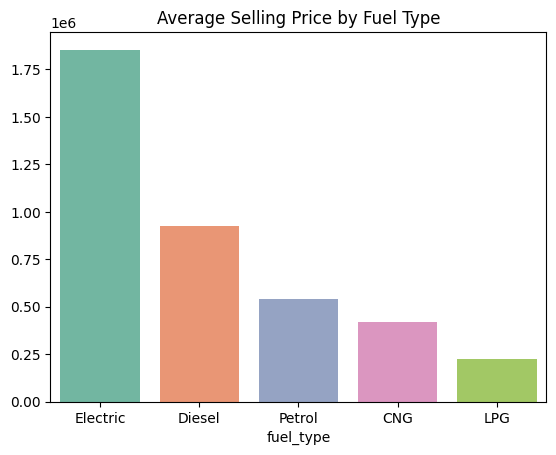

In [34]:
sns.barplot(
    x=avg_price.index,
    y=avg_price.values,
    palette='Set2'
)
plt.title('Average Selling Price by Fuel Type')
plt.savefig('plot2_avg_price_by_fuel_type.png')

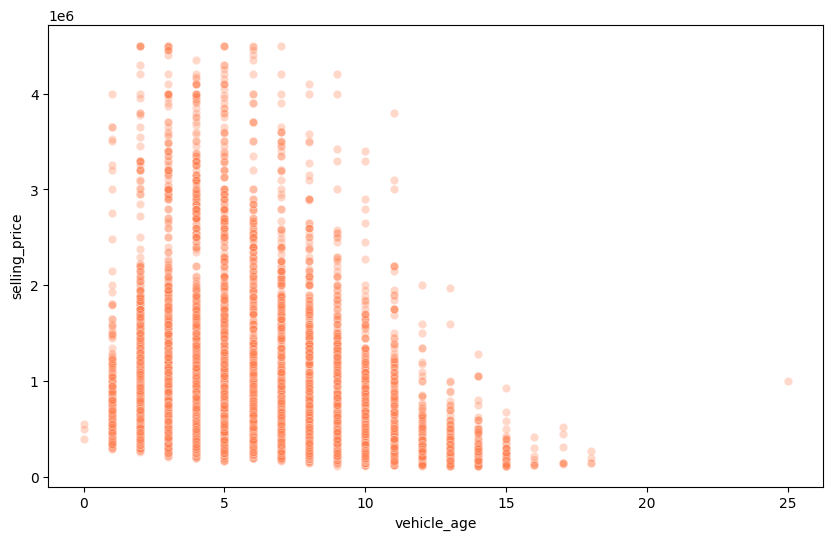

In [35]:
plt.figure(figsize=(10, 6))
sns.scatterplot(
    x='vehicle_age',
    y = 'selling_price',
    data=df,
    alpha=0.3,
    color='coral'
)
plt.savefig('plot3_selling_price_vs_vehicle_age.png')

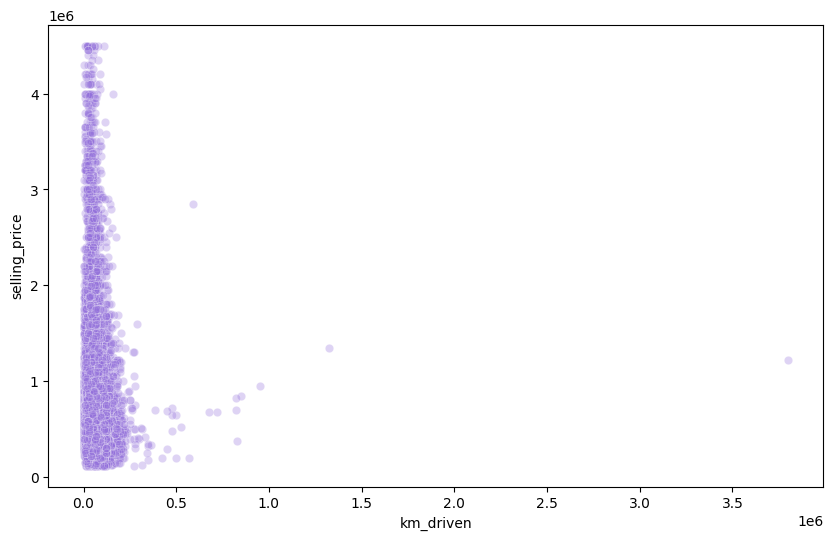

In [36]:
plt.figure(figsize=(10, 6))
sns.scatterplot(
    x='km_driven',
    y = 'selling_price',
    data=df,
    alpha=0.3,
    color='mediumpurple'
)
plt.savefig('plot4_selling_price_vs_km_driven.png')

In [37]:
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
df[numeric_cols].corr()

,vehicle_age,km_driven,mileage,engine,max_power,seats,selling_price
vehicle_age,1.000000,0.333291,-0.273549,0.152421,0.062584,0.042414,-0.275397
km_driven,0.333291,1.000000,-0.112122,0.223447,0.079865,0.193400,-0.053439
mileage,-0.273549,-0.112122,1.000000,-0.635163,-0.537635,-0.452139,-0.335588
engine,0.152421,0.223447,-0.635163,1.000000,0.790925,0.592937,0.620353
max_power,0.062584,0.079865,-0.537635,0.790925,1.000000,0.205284,0.765478
seats,0.042414,0.193400,-0.452139,0.592937,0.205284,1.000000,0.207242
selling_price,-0.275397,-0.053439,-0.335588,0.620353,0.765478,0.207242,1.000000


In [38]:
plt.figure(figsize=(10, 6))
sns.heatmap(df[numeric_cols].corr(), annot=True, fmt=".2f", cmap='coolwarm', cbar=True)
plt.title('Correlation Heatmap of Numeric Features')
plt.tight_layout()
plt.savefig('plot5_correlation_heatmap.png')
plt.close()

In [39]:
df.head()

,brand,vehicle_age,km_driven,seller_type,fuel_type,transmission_type,mileage,engine,max_power,seats,selling_price
0,Maruti,9,120000,Individual,Petrol,Manual,19.70,796,46.30,5,120000
1,Hyundai,5,20000,Individual,Petrol,Manual,18.90,1197,82.00,5,550000
2,Hyundai,11,60000,Individual,Petrol,Manual,17.00,1197,80.00,5,215000
3,Maruti,9,37000,Individual,Petrol,Manual,20.92,998,67.10,5,226000
4,Ford,6,30000,Dealer,Diesel,Manual,22.77,1498,98.59,5,570000


In [40]:
cat_cols = ['brand','seller_type', 'fuel_type', 'transmission_type']
cat_cols

['brand', 'seller_type', 'fuel_type', 'transmission_type']

In [41]:
le = LabelEncoder()
for col in cat_cols:
    df[col] = le.fit_transform(df[col])
    print(f"Encoded {col} with LabelEncoder.")

Encoded brand with LabelEncoder.
Encoded seller_type with LabelEncoder.
Encoded fuel_type with LabelEncoder.
Encoded transmission_type with LabelEncoder.


In [42]:
df

,brand,vehicle_age,km_driven,seller_type,fuel_type,transmission_type,mileage,engine,max_power,seats,selling_price
0,16,9,120000,1,4,1,19.70,796,46.30,5,120000
1,6,5,20000,1,4,1,18.90,1197,82.00,5,550000
2,6,11,60000,1,4,1,17.00,1197,80.00,5,215000
3,16,9,37000,1,4,1,20.92,998,67.10,5,226000
4,4,6,30000,0,1,1,22.77,1498,98.59,5,570000
...,...,...,...,...,...,...,...,...,...,...,...
15406,6,9,10723,0,4,1,19.81,1086,68.05,5,250000
15407,16,2,18000,0,4,1,17.50,1373,91.10,7,925000
15408,22,6,67000,0,1,1,21.14,1498,103.52,5,425000
15409,15,5,3800000,0,1,1,16.00,2179,140.00,7,1225000


In [43]:
df['price_per_km'] = df['selling_price'] / (df['km_driven'] + 1)

In [44]:
df.head()

,brand,vehicle_age,km_driven,seller_type,fuel_type,transmission_type,mileage,engine,max_power,seats,selling_price,price_per_km
0,16,9,120000,1,4,1,19.70,796,46.30,5,120000,0.999992
1,6,5,20000,1,4,1,18.90,1197,82.00,5,550000,27.498625
2,6,11,60000,1,4,1,17.00,1197,80.00,5,215000,3.583274
3,16,9,37000,1,4,1,20.92,998,67.10,5,226000,6.107943
4,4,6,30000,0,1,1,22.77,1498,98.59,5,570000,18.999367


In [45]:
X = df.drop(columns=['selling_price'])
y = df['selling_price']

In [46]:
X = X.drop(columns=['price_per_km'])  # Dropping 'price_per_km' to avoid data leakage

In [47]:
print(f'X shape: {X.shape}')
print(f'y shape: {y.shape}')

X shape: (14957, 10)
y shape: (14957,)


In [48]:
print(f'Feature columns used for model training: {X.columns.tolist()}')

Feature columns used for model training: ['brand', 'vehicle_age', 'km_driven', 'seller_type', 'fuel_type', 'transmission_type', 'mileage', 'engine', 'max_power', 'seats']


In [49]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [50]:
print(f"Training samples : {X_train.shape[0]}")
print(f"Testing samples : {X_test.shape[0]}")

Training samples : 11965
Testing samples : 2992


In [51]:
model = RandomForestRegressor(n_estimators=100, random_state=42)
print('Training the model... this may take a few minutes depending on the dataset size.')
model.fit(X_train, y_train)
print('Model training completed.')

Training the model... this may take a few minutes depending on the dataset size.
Model training completed.


In [53]:
y_pred = model.predict(X_test)
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print(f"Mean Absolute Error (MAE): {mae:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.2f}")
print(f"R-squared (R2): {r2:.4f}")

Mean Absolute Error (MAE): 92457.31
Root Mean Squared Error (RMSE): 159675.75
R-squared (R2): 0.9240


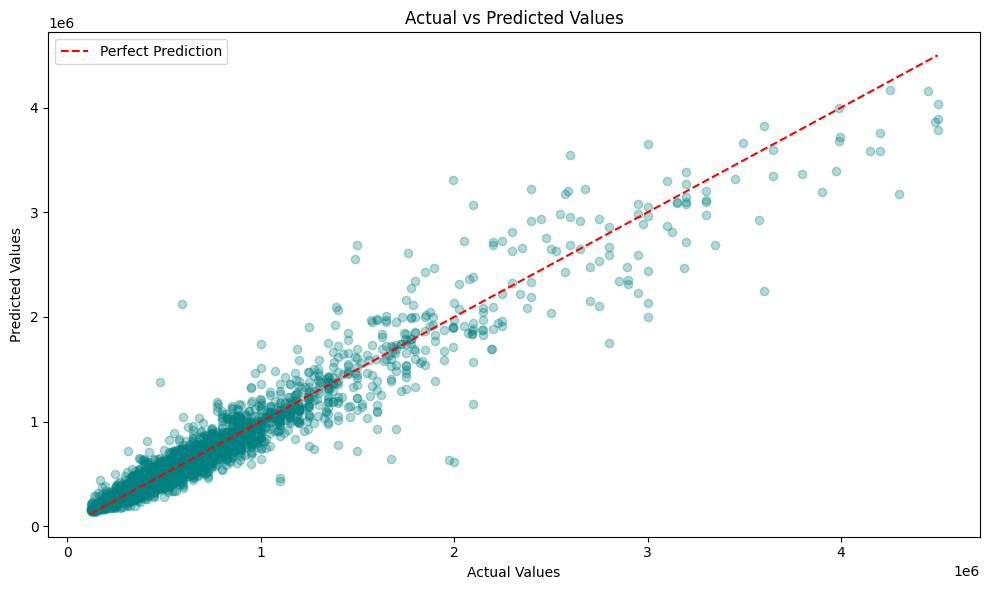

In [54]:
plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred, alpha=0.3, color='teal')
min_val = min(y_test.min(), y_pred.min())
max_val = max(y_test.max(), y_pred.max())
plt.plot([min_val, max_val], [min_val, max_val], 'r--', label='Perfect Prediction')
plt.xlabel('Actual Values')
plt.ylabel('Predicted Values')
plt.title('Actual vs Predicted Values')
plt.legend()
plt.tight_layout()
plt.savefig('plot6_actual_vs_predicted.png')
plt.show()

In [60]:
importances = model.feature_importances_
feat_names = X.columns.tolist()
sorted_idx = np.argsort(importances)[::-1]

In [64]:
plt.figure(figsize=(10, 6))
sns.barplot(x=importances[sorted_idx], y=np.array(feat_names)[sorted_idx], palette='viridis')
plt.title('Feature Importances(Which columns matter the most for predicting selling price)')
plt.xlabel('Importance Score')
plt.ylabel('Features')
plt.tight_layout()
plt.savefig('plot7_feature_importances.png')
plt.close()
print("Saved plot: plot7_feature_importances.png")

Saved plot: plot7_feature_importances.png


In [76]:
param_grid = {
    'n_estimators' : [100,200],
    'max_depth' : [None, 10, 20],
    'min_samples_split' : [2, 5]
}

grid_search = GridSearchCV(
    estimator = RandomForestRegressor(random_state=42),
    param_grid = param_grid,
    cv = 3,
    scoring = 'r2',
    n_jobs = -1,
    verbose = 1
)

In [77]:
grid_search.fit(X_train, y_train)
print(f"Best parameters found: {grid_search.best_params_}")
print(f'Best CV R2 score: {grid_search.best_score_:.4f}')

Fitting 3 folds for each of 12 candidates, totalling 36 fits
Best parameters found: {'max_depth': None, 'min_samples_split': 5, 'n_estimators': 200}
Best CV R2 score: 0.9228


In [78]:
best_model = grid_search.best_estimator_
y_pred_best = best_model.predict(X_test)
mae_best = mean_absolute_error(y_test, y_pred_best)
rmse_best = np.sqrt(mean_squared_error(y_test, y_pred_best))
r2_best = r2_score(y_test, y_pred_best)

print(f"Best Model Mean Absolute Error (MAE): {mae_best:.2f}")
print(f"Best Model Root Mean Squared Error (RMSE): {rmse_best:.2f}")
print(f"Best Model R-squared (R2): {r2_best:.4f}")

Best Model Mean Absolute Error (MAE): 90755.35
Best Model Root Mean Squared Error (RMSE): 157232.43
Best Model R-squared (R2): 0.9263


In [79]:
model_comparisons = pd.DataFrame({
    'Model': ['Initial Model', 'Best Model'],
    'MAE': [mae, mae_best],
    'RMSE': [rmse, rmse_best],
    'R2': [r2, r2_best]
})
model_comparisons

,Model,MAE,RMSE,R2
0,Initial Model,92457.306497,159675.748744,0.923979
1,Best Model,90755.345484,157232.431414,0.926287


In [80]:
joblib.dump(best_model, 'best_car_price_model.pkl')
print("Saved the best model to 'best_car_price_model.pkl' for future use.")

Saved the best model to 'best_car_price_model.pkl' for future use.


In [81]:
loaded_model = joblib.load('best_car_price_model.pkl')

In [82]:
loaded_model

RandomForestRegressor(min_samples_split=5, n_estimators=200, random_state=42)

In [84]:
new_car = pd.DataFrame({
    'brand' : [0],
    'vehicle_age' : [5],
    'km_driven' : [50000],
    'seller_type' : [1],
    'fuel_type' : [2],
    'transmission_type' : [1],
    'mileage' : [18.0],
    'engine' : [1500],
    'max_power' : [100],
    'seats' : [5]
})
new_car

,brand,vehicle_age,km_driven,seller_type,fuel_type,transmission_type,mileage,engine,max_power,seats
0,0,5,50000,1,2,1,18.0,1500,100,5


In [85]:
predicted_price = loaded_model.predict(new_car)
print('New Car details:', new_car.to_string(index=False))
print(f'Predicted Selling Price for the new car: {predicted_price[0]:.2f}')

New Car details:  brand  vehicle_age  km_driven  seller_type  fuel_type  transmission_type  mileage  engine  max_power  seats
     0            5      50000            1          2                  1     18.0    1500        100      5
Predicted Selling Price for the new car: 658647.84
